# Particulate matter (PM) 2.5 target of 10 μg/m<sup>3</sup> within reach for Shoreditch and surrounding districts

**By Andrew Sivanesan**

::: {.figure}
![](images/ShoreditchHighStreet.jpg)

<span>
Bridge over Brick Lane at Shoreditch High Street station, 2010.<br>
© Copyright Ben Brooksbank and licensed for reuse under this Creative Commons Licence.
</span>

:::

## Executive summary

The London Enviroment Strategy: Fourth Progress Report states that "the Mayor aims for the capital to have the best air quality of any major world city, going beyond the legal requirements to protect human health and
minimise inequalities" [@LondonEnvironmentStrategy4]. With this in mind: efforts to reduce the annual average concentrations of particulate matter (PM) 2.5 should be targeted at **Shoreditch, Whitechapel, Hoxton, Haggerston and Bethnal Green**. See @fig-choropleth for an interactive map. See @sec-analysis for step-by-step data analyis.

Analysis of data from the London Atmospheric Emissions Inventory (LAEI) 2022 shows that these five districts have the **highest annual average concentrations of particulate matter (PM 2.5) in Tower Hamlets and Hackney - two of the most deprived boroughs in London** [@MinistryHousingCommunitiesLocalGovt]. While these five districts are achieving the World Health Organisation's (WHO) third interim target of between 10 and 15 μg/m<sup>3</sup> [@WorldHealthOrganization2], they are **within 1 μg/m<sup>3</sup> of achieving the fourth interim target of between 5 and 10 μg/m<sup>3</sup>.** For context: the fourth interim target is being achieved by the rest of Tower Hamlets and Hackney. It is also an **important step towards achieving the World Health Organisation's Air Quality Guideline of less than 5 μg/m<sup>3</sup>, which minimises negative health impacts from PM 2.5.**

### Recommendation

An example of air quality improvement activity may include a public awareness campaign in the heart of east London reminding local residents of the London Assembly's recommendations for improving air quality [@LondonAssembly]: listed below for ease of reference.

* Walk, cycle and scoot more, and avoid the busiest roads and times when you can
* Use public transport where you can, but if you do have to drive, switch your engine off when you’re stationary.

It's recommended that any air quality improvement activities in these districts are done in partnership with community-led initiatives such as Breathe London Communities [@BreatheLondonCommunities] to ensure relevance to, and buy-in from, local residents.

## What is PM 2.5?

PM 2.5 are fine particles with a diameter of 2.5 micrometres or less: meaning they are small enough to enter the bloodstream and get lodged in major organs such as the heart and brain. Typical sources of PM 2.5 include brake wear and tyre wear from road vehicles. Young children, the elderly and those with respiratory conditions (e.g. asthma) are at most risk of illness from PM 2.5 [@DEFRA]. Therefore, **reducing PM 2.5 near schools, hospitals and care homes is a priority.**

Concentrations of a variety of pollutants - including PM 2.5 - tend to be higher in built-up inner city areas due to a combination of road traffic congestion (e.g. engine idling, repetitive braking) and lack of open space for pollutants to disperse into the surrounding atmosphere.

## Why focus on PM 2.5?

A combination of health-based international guidelines, transport research and European legislation motivate a focus on PM 2.5. According to the World Health Organization, "the burden of disease attributable to air pollution is now estimated to be on a par with other major global health risks such as unhealthy diet and tobacco smoking, and air pollution is now recognized as the single biggest environmental threat to human health" [@WorldHealthOrganization1]. They set interim targets and air quality guidelines for a variety of pollutants including PM 2.5 [@WorldHealthOrganization2]. Non-exhaust emissions (NEEs) - particles from brake, tyre and road wear – are now a dominant source of urban particulate matter (PM) in Europe [@EITUrbanMobility]. Furthermore, the Euro 7 emissions standard - which specifies rules for road vehicle emissions limits - will come into effect in a phased manner from November 2026 onwards. Euro 7 includes limits on emissions from brake wear and tyre wear: key sources of PM 2.5 [@EuropeanCouncil]. 

## Why focus on Tower Hamlets and Hackney?

Tower Hamlets and Hackney are the two most deprived boroughs regarding income deprivation among children [@MinistryHousingCommunitiesLocalGovt]. Therefore, targeting air quality improvement efforts at these two London boroughs aligns with the Mayor's aim "for the capital to have the best air quality of any major world city, going beyond the legal requirements to protect human health and minimise inequalities" [@LondonEnvironmentStrategy4].

## Methodology {#sec-analysis}

This analysis uses the following techniques:

* spatial joins in GeoPandas,
* summary statistics in Pandas, Matplotlib and Seaborn, and
* interative map visualisation in Folium.

### Import modules

In [3]:
import pandas as pd
import geopandas as gpd
import folium
import seaborn as sns
import matplotlib.pyplot as plt

### Read in LAEI 2019 grid square shapefile

These are 1 km x 1 km squares defined using the **British National Grid (BNG) coordinate reference system.** Coordinates are expressed as eastings and northings. The 1km2_IDs - which are unique to each grid square - increase from west and east and north to south.

The area covered by the London Atmospheric Emissions Inventory (LAEI) includes **Greater London (the 32 London boroughs and the City of London) as well as areas outside Greater London up to the M25 motorway.** [@LAEI]

In [4]:
fname_grid = "LAEI2019_grid.shp"

In [5]:
grid = gpd.read_file(fname_grid)
grid = grid[grid["Borough"].isin(["Tower Hamlets", "Hackney"])]
grid.head()

,Grid_ID_19,GridIdEx,1km2_ID,Easting,Northing,Area_km2,Borough,Zone,geometry
2764,2765,692,8513,533500,188500,0.06,Hackney,InnerULEX,"MULTIPOLYGON (((534000.003 188000.005, 533419...."
2779,2780,732,8855,531500,186500,0.21,Hackney,InnerULEX,"POLYGON ((531999.998 186401.602, 531901.503 18..."
2782,2783,735,8857,533500,186500,1.00,Hackney,InnerULEX,"POLYGON ((534000.003 185999.997, 533000.001 18..."
2783,2784,736,8859,535500,186500,0.77,Hackney,InnerULEX,"POLYGON ((535999.999 186554.499, 535999.999 18..."
2786,2787,739,8861,537500,186500,0.04,Hackney,InnerULEX,"POLYGON ((537306.404 185999.997, 537000.001 18..."


### Read in PM 2.5 annual average concentrations data

This data is high data resolution: one data point per 20 metre x 20 metre square. There are around 6 million rows of data in the original dataset (which covers the whole of London), which exceeds the 100 MB file size limit in GitHub. Therefore, the data was split into smaller chunks that could be uploaded to GitHub.

In [6]:
chunks = range(1, 12)

# Define an easting and northing box for Tower Hamlets and Hackney
# According to the English indices of deprivation 2025 these are the two most deprived regarding 
# income deprivation among children
min_easting = 530000
max_easting = 540000
min_northing = 178000
max_northing = 188000

# read in first chunk
df = pd.read_csv("LAEI2022_V1_PM25_chunk_0.csv").rename(columns={"x": "Easting", "y": "Northing"})

# append remaining chunks
for c in chunks:
    add_df = pd.read_csv(f"LAEI2022_V1_PM25_chunk_{c}.csv").rename(columns={"x": "Easting", "y": "Northing"})
    df = pd.concat([df, add_df])

# define filter condition for the easting and northing box
cond = (df["Easting"].between(min_easting, max_easting)) & (df["Northing"].between(min_northing, max_northing))

df = df[cond]

df.head()

,Easting,Northing,conc
195398,530000,188000,9.581474
195399,530020,188000,9.411696
195400,530040,188000,9.351303
195401,530060,188000,9.332762
195402,530080,188000,9.329437


### Perform spatial join

Convert from Pandas DataFrame to GeoPandas DataFrame. This creates a Point object for each data point, which will be used in a spatial join between the LAEI 2019 grid squares and the PM 2.5 concentrations data. As mentioned previously: the coordinate reference system is British National Grid (EPSG:27700). The spatial join will map each PM 2.5 concentration data point to a LAEI 2019 grid square (and, by extension, a London borough).

In [9]:
gdf = gpd.GeoDataFrame(df,
                       geometry=gpd.points_from_xy(df["Easting"], df["Northing"]),
                       crs="EPSG:27700")

gdf.head()

,Easting,Northing,conc,geometry
195398,530000,188000,9.581474,POINT (530000 188000)
195399,530020,188000,9.411696,POINT (530020 188000)
195400,530040,188000,9.351303,POINT (530040 188000)
195401,530060,188000,9.332762,POINT (530060 188000)
195402,530080,188000,9.329437,POINT (530080 188000)


In [8]:
grid_contains_points = grid.sjoin(gdf, how="inner", predicate="contains")

grid_contains_points.head()

,Grid_ID_19,GridIdEx,1km2_ID,Easting_left,Northing_left,Area_km2,Borough,Zone,geometry,index_right,Easting_right,Northing_right,conc
2779,2780,732,8855,531500,186500,0.21,Hackney,InnerULEX,"POLYGON ((531999.998 186401.602, 531901.503 18...",433840,531900,186380,11.285640
2779,2780,732,8855,531500,186500,0.21,Hackney,InnerULEX,"POLYGON ((531999.998 186401.602, 531901.503 18...",433841,531920,186380,10.262810
2779,2780,732,8855,531500,186500,0.21,Hackney,InnerULEX,"POLYGON ((531999.998 186401.602, 531901.503 18...",430853,531880,186400,11.863350
2779,2780,732,8855,531500,186500,0.21,Hackney,InnerULEX,"POLYGON ((531999.998 186401.602, 531901.503 18...",430855,531920,186400,9.997118
2779,2780,732,8855,531500,186500,0.21,Hackney,InnerULEX,"POLYGON ((531999.998 186401.602, 531901.503 18...",430854,531900,186400,10.211490


### Calculate median PM 2.5 concentrations for each LAEI 2019 grid square

In order to produce a summary visualisation for each LAEI 2019 grid square we need to summarise the PM 2.5 concentrations for each LAEI 2019 grid square. The median (middle) value provides a representative PM 2.5 concentration for each LAEI 2019 grid square that isn't skewed by the distribution of concentrations (including outliers).

A box plot of the median PM 2.5 concentrations is used to sense-check the distribution of median PM 2.5 concentrations.

In [68]:
# This cell is split into two lines of code purely for the benefit of readability
median_conc_per_grid_square = gpd.GeoDataFrame(grid_contains_points.groupby(["1km2_ID", "geometry", "Borough"])["conc"].median().reset_index())
median_conc_per_grid_square = median_conc_per_grid_square.rename(columns={"conc": "Median_PM2.5_concentration"})
median_conc_per_grid_square["Median_PM2.5_concentration"] = round(median_conc_per_grid_square["Median_PM2.5_concentration"], 2)
#median_conc_per_grid_square.head()

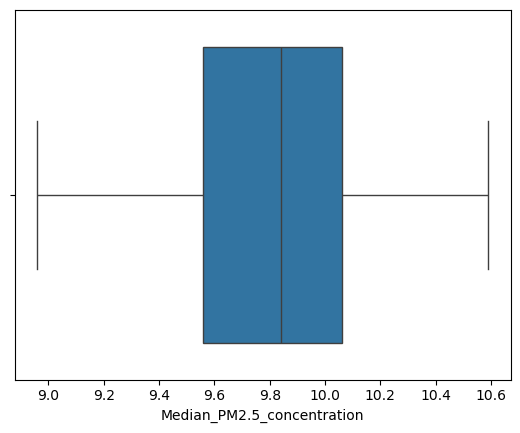

In [69]:
# Median PM 2.5 concentrations are symmetrical: centred on 9.8 micrograms per cubic metre
# PM 2.5 concentrations straddle interim target 4 (10 micrograms per cubic metre) and interim target 3 (15 grams per cubic metre)
sns.boxplot(data=median_conc_per_grid_square, x="Median_PM2.5_concentration")
plt.show()

### Categorise each grid square relative to the WHO 2021 interim targets and air quality guideline (AQG)

The PM 2.5 concentrations for each LAEI 2019 grid square are compared against the interim targets and air quality guideline from the World Health Organizaton.

The WHO_guideline_categoriser function will be used to produce values in the tooltip in the interactive choropleth map at the end of this notebook.

The WHO_target_value function will be used to colour the LAEI 2019 grid squares in the interative choropleth map at the end of this notebook.

A summary count is performed to gauge how many grid squares are mapped to each interim target or air quality guideline.

In [71]:
def WHO_guideline_categoriser(conc):
    """
    This function categorises whether an annual average 
    PM 2.5 concentration meets the four interim targets or 
    the air quality guideline (AQG) level set by the World 
    Health Organisation in 2021.

    Parameters:

    conc (float): Annual average PM 2.5 concentration in micrograms per cubic metre.

    Returns:

    out (str): String indicating which PM 2.5 annual average concentration target has been met. 
    
    """
    if conc < 5:
        out = "AQG guideline (5 micrograms per cubic metre)"
    elif 5 <= conc < 10:
        out = "Interim target 4 (10 micrograms per cubic metre)."
    elif 10 <= conc < 15:
        out = "Interim target 3 (15 micrograms per cubic metre)."
    elif 15 <= conc < 25:
        out = "Interim target 2 (25 micrograms per cubic metre)."
    elif 25 <= conc < 35:
        out = "Interim target 1 (35 micrograms per cubic metre)."
    elif conc >= 35:
        out = "Not achieving interim targets."

    return out

In [72]:
def WHO_target_value(conc):
    """
    This function categorises whether an annual average 
    PM 2.5 concentration meets the four interim targets or
    the air quality guideline (AQG) level set by the World 
    Health Organisation in 2021.

    Parameters:

    conc (float): Annual average PM 2.5 concentration in micrograms per cubic metre.

    Returns:

    out (str): Integer indicating which PM 2.5 annual average concentration target has been met. 
    
    """
    if conc < 5:
        out = None
    elif 5 <= conc < 10:
        out = 4
    elif 10 <= conc < 15:
        out = 3
    elif 15 <= conc < 25:
        out = 2
    elif 25 <= conc < 35:
        out = 1
    elif conc >= 35:
        out = None

    return out

In [73]:
median_conc_per_grid_square["Target"] = median_conc_per_grid_square.apply(lambda x: WHO_guideline_categoriser(x["Median_PM2.5_concentration"]), axis=1)
median_conc_per_grid_square["TargetValue"] = median_conc_per_grid_square.apply(lambda x: WHO_target_value(x["Median_PM2.5_concentration"]), axis=1)

In [74]:
# 53 out of 73 grid squares in Tower Hamlets and Hackney meet interim target 4 (10 micrograms per cubic metre)
# All grid squares in Tower Hamlets and Hackney meet either interim target 4 (10 micrograms per cubic metre) or interim target 3 (15 micrograms per cubic metre)
median_conc_per_grid_square.groupby("Target").count()

,1km2_ID,geometry,Borough,Median_PM2.5_concentration,TargetValue
Target,,,,,
Interim target 3 (15 micrograms per cubic metre).,20,20,20,20,20
Interim target 4 (10 micrograms per cubic metre).,53,53,53,53,53


In [75]:
median_conc_per_grid_square.groupby("TargetValue").count()

,1km2_ID,geometry,Borough,Median_PM2.5_concentration,Target
TargetValue,,,,,
3,20,20,20,20,20
4,53,53,53,53,53


### Visualise the median PM 2.5 concentrations on an interactive choropleth map

The choropleth map reveals a hotspot (blue squares) in the south-west of Hackney and north-west of Tower Hamlets. This includes the five districts of **Shoreditch, Whitechapel, Hoxton, Haggerston and Bethnal Green.** They are **achieving interim target 3 (10 to 15 μg/m<sup>3</sup>)** whereas the rest of Tower Hamlets and Hackney are achieving interim target 4 (5 to 10 μg/m<sup>3</sup>) (yellow squares). Hover your cursor over each square to get additional information via the tooltip.

Please note that some grid squares (e.g. at the boundary between Tower Hamlets and Hackney) contain more than one polygon. **The colour of the LAEI 2019 grid square is based on the polygon with the highest median annual average concentration of PM 2.5 within the square (even if that polygon constitutes a very small portion of the square)**. Examples include LAEI grid IDs 9373 and 9374 (Tower Hamlets/Hackney).

In [95]:
#| label: fig-choropleth
#| fig-cap: "Blue cells indicate higher PM 2.5 concentrations."
#| fig-alt: "Choropleth map of PM 2.5 concentrations in Tower Hamlets and Hackney relative to the World Health Organisation's PM 2.5 interim targets."

london_centre = [51.51, -0.12]

# these two functions will be used in the tooltip
style_function = lambda x: {'fillColor': '#ffffff', 
                            'color':'#000000', 
                            'fillOpacity': 0.1, 
                            'weight': 0.1}

highlight_function = lambda x: {'fillColor': '#000000', 
                                'color':'#000000', 
                                'fillOpacity': 0.50, 
                                'weight': 0.1}

m = folium.Map(location=london_centre, zoom_start=11)

folium.Choropleth(
    geo_data=median_conc_per_grid_square,
    name="Median PM 2.5 concentrations",
    data=median_conc_per_grid_square,
    #columns=["1km2_ID", "Median_PM2.5_concentration"],
    columns=["1km2_ID", "TargetValue"],
    key_on="feature.properties.1km2_ID",
    fill_color="plasma",
    legend_name="WHO interim target").add_to(m)

folium.LayerControl().add_to(m)

tooltip = folium.features.GeoJson(median_conc_per_grid_square,
                                  style_function=style_function, 
                                  control=False,
                                  highlight_function=highlight_function, 
                                  tooltip=folium.features.GeoJsonTooltip(
                                      fields=["Borough", "1km2_ID", "Median_PM2.5_concentration", "Target"],
                                      style=("background-color: white; color: #333333; font-family: arial; font-size: 12px; padding: 10px;") 
                                  )
                                 )
m.add_child(tooltip)

m

## References